<>:57: SyntaxWarning: invalid escape sequence '\j'
<>:57: SyntaxWarning: invalid escape sequence '\j'
C:\Users\junyew\AppData\Local\Temp\ipykernel_20152\2155106337.py:57: SyntaxWarning: invalid escape sequence '\j'
  plt.savefig('C:\jwang\image1.jpeg')


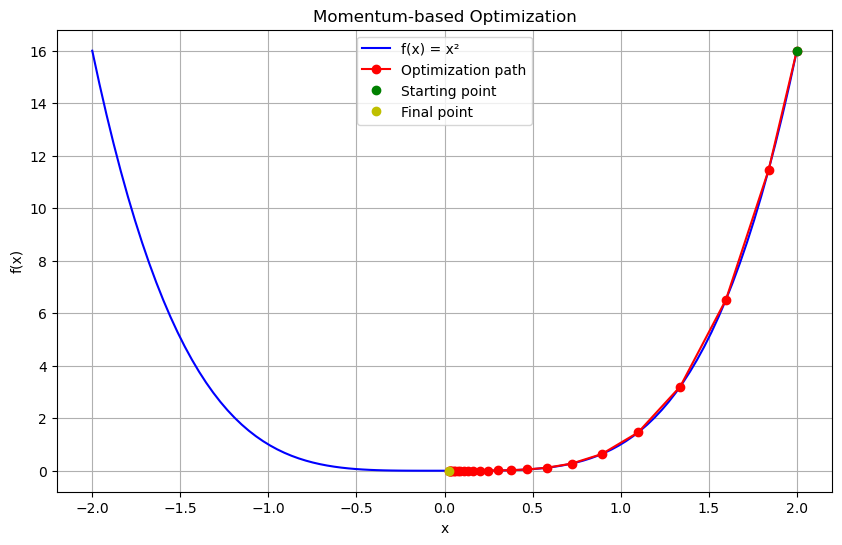

Starting point: 2.0
Final point: 0.025801891148305913
Final value: 4.432065345169363e-07


In [53]:
#Momentum-based Gradient Descent 
#Import libraries
import numpy as np
import matplotlib.pyplot as plt

class MomentumOptimizer:
    def __init__(self, learning_rate=0.01, momentum=0.8, tolerance=1e-6):
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.velocity = 0
        self.tolerance = tolerance  # Convergence tolerance
        
    def optimize(self, x_start, gradient_func, max_iterations=200):
        x = x_start
        history = [x]
        
        for _ in range(max_iterations):
            gradient = gradient_func(x)
            self.velocity = self.momentum * self.velocity - self.learning_rate * gradient
            x_new = x + self.velocity
            history.append(x_new)
            # Check for convergence
            if abs(x_new - x) < self.tolerance or abs(gradient) < self.tolerance:
                break
            x = x_new
        return history

# Define the function and its gradient
def example_function(x):
    return x**4

#def example_gradient(x):
#    return 2*x

def derivative(x):
	return x**4

# Create and run optimizer
optimizer = MomentumOptimizer(learning_rate=0.01, momentum=0.8, tolerance=1e-6)
initial_x = 2.0
history = optimizer.optimize(initial_x, derivative, max_iterations=200)

# Plotting code
x_values = np.linspace(-2, 2, 100)
y_values = example_function(x_values)

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, 'b-', label='f(x) = x²')
plt.plot(history, [example_function(x) for x in history], 'ro-', label='Optimization path')
plt.plot(initial_x, example_function(initial_x), 'go', label='Starting point')
plt.plot(history[-1], example_function(history[-1]), 'yo', label='Final point')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Momentum-based Optimization')
plt.legend()
plt.grid(True)
plt.savefig('C:\jwang\image1.jpeg')
plt.show()

# Print results
print(f"Starting point: {initial_x}")
print(f"Final point: {history[-1]}")
print(f"Final value: {example_function(history[-1])}")

<>:92: SyntaxWarning: invalid escape sequence '\j'
<>:92: SyntaxWarning: invalid escape sequence '\j'
C:\Users\junyew\AppData\Local\Temp\ipykernel_6396\3568174620.py:92: SyntaxWarning: invalid escape sequence '\j'
  plt.savefig('C:\jwang\image1.jpeg')


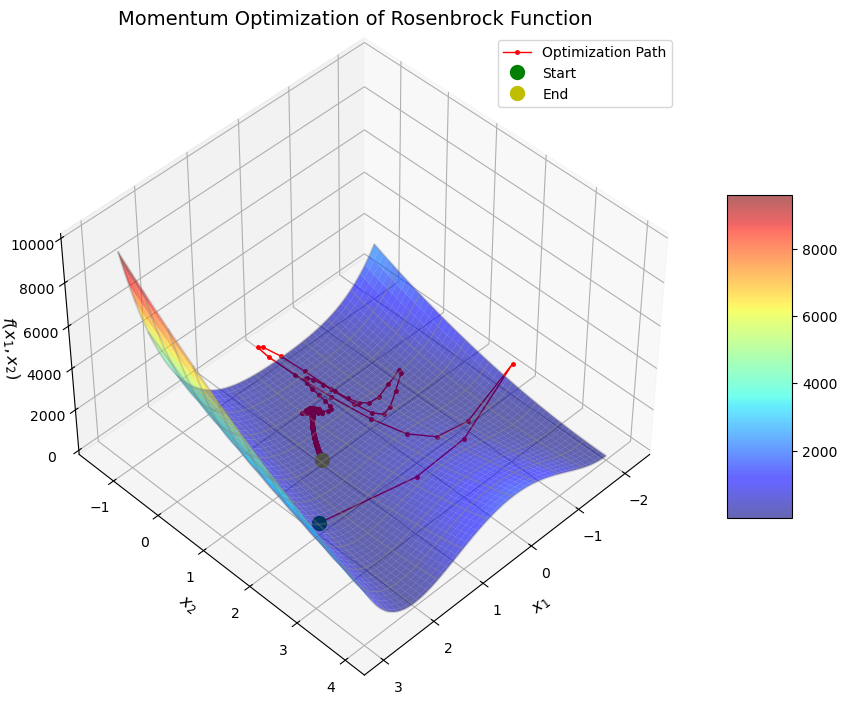

Starting point: [2.0, 2.0]
Final point: [0.994368802719395, 0.9887467045213755]
Final value: 3.176150990289171e-05


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Define the Rosenbrock function and its gradient
def rosenbrock(x):
    x1, x2 = x[0], x[1]
    return 100 * (x2 - x1**2)**2 + (x1 - 1)**2

def rosenbrock_gradient(x):
    """Gradient of the Rosenbrock function."""
    x1, x2 = x[0], x[1]
    df_dx1 = -400 * x1 * (x2 - x1**2) + 2 * (x1 - 1)
    df_dx2 = 200 * (x2 - x1**2)
    return np.array([df_dx1, df_dx2])

# Momentum Optimizer class
class MomentumOptimizer:
    def __init__(self, learning_rate=0.001, momentum=0.9, tolerance=1e-6):
        """Initialize momentum-based optimizer.
        
        Args:
            learning_rate (float): Step size for gradient updates.
            momentum (float): Momentum coefficient for velocity.
            tolerance (float): Convergence tolerance.
        """
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.velocity = np.zeros(2)
        self.tolerance = tolerance
        
    def optimize(self, x_start, gradient_func, max_iterations=1000):
        """Optimize a function using momentum gradient descent.
        
        Args:
            x_start (array): Initial point [x1, x2].
            gradient_func (callable): Gradient of the objective function.
            max_iterations (int): Maximum number of iterations.
        
        Returns:
            np.ndarray: History of points visited during optimization.
        """
        x = np.array(x_start, dtype=float)
        history = [x.copy()]
        
        for i in range(max_iterations):
            grad = gradient_func(x)
            self.velocity = self.momentum * self.velocity - self.learning_rate * grad
            x_new = x + self.velocity
            history.append(x_new.copy())
            if np.linalg.norm(x_new - x) < self.tolerance or np.linalg.norm(grad) < self.tolerance:
                print(f"Converged after {i+1} iterations")
                break
            x = x_new
        return np.array(history)

# Set up grid for plotting
x1m = np.linspace(-2, 3, 100)
x2m = np.linspace(-1, 4, 100)
X1, X2 = np.meshgrid(x1m, x2m)
Z = rosenbrock([X1, X2])

# Optimize
optimizer = MomentumOptimizer(learning_rate=0.001, momentum=0.9, tolerance=1e-6)
initial_x = [2.0, 2.0]
history = optimizer.optimize(initial_x, rosenbrock_gradient, max_iterations=1000)

# Plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X1, X2, Z, cmap='jet', alpha=0.6, edgecolor='none')
ax.plot_wireframe(X1, X2, Z, rstride=10, cstride=10, color='gray', alpha=0.3)

# Plot optimization path
x_path, y_path = history[:, 0], history[:, 1]
z_path = rosenbrock([x_path, y_path])
ax.plot(x_path, y_path, z_path, 'r.-', label='Optimization Path', linewidth=1, markersize=5)
ax.plot([initial_x[0]], [initial_x[1]], [rosenbrock(initial_x)], 'go', label='Start', markersize=10)
ax.plot([history[-1, 0]], [history[-1, 1]], [rosenbrock(history[-1])], 'yo', label='End', markersize=10)

# Customize plot
ax.set_xlabel('$x_1$', fontsize=12)
ax.set_ylabel('$x_2$', fontsize=12)
ax.set_zlabel('$f(x_1, x_2)$', fontsize=12)
ax.set_title('Momentum Optimization of Rosenbrock Function', fontsize=14)
ax.legend()
ax.view_init(elev=45, azim=45)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.tight_layout()
plt.savefig('rosenbrock_optimization.pdf', dpi=300)  # Save for publication
#plt.savefig('C:\jwang\rosebrock.jpeg')
plt.savefig('C:\jwang\image1.jpeg')
plt.show()

# Results
print(f"Starting point: {initial_x}")
print(f"Final point: {history[-1].tolist()}")
print(f"Final value: {rosenbrock(history[-1])}")

<>:96: SyntaxWarning: invalid escape sequence '\j'
<>:96: SyntaxWarning: invalid escape sequence '\j'
C:\Users\junyew\AppData\Local\Temp\ipykernel_6396\2463431946.py:96: SyntaxWarning: invalid escape sequence '\j'
  plt.savefig('C:\jwang\side_by_side_3d_convergence.png')


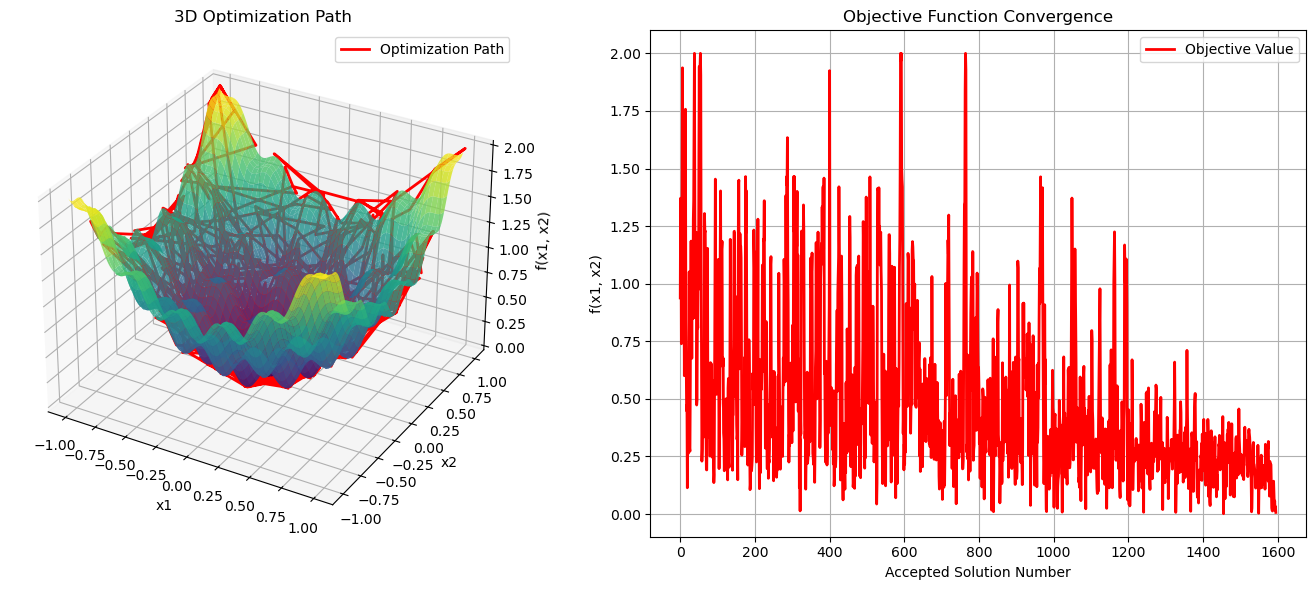

Best solution: [ 0.01537409 -0.01202313]
Best objective: 0.007107372019647812
Number of accepted points: 1596


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import random
import math

# Define objective function
def f(x):
    x1 = x[0]
    x2 = x[1]
    obj = 0.2 + x1**2 + x2**2 - 0.1*math.cos(6.0*3.1415*x1) - 0.1*math.cos(6.0*3.1415*x2)
    return obj

# Start location
x_start = [0.7, -0.6]

# Mesh for surface plot
ii1 = np.arange(-1.0, 1.0, 0.01)
ii2 = np.arange(-1.0, 1.0, 0.01)
x1g, x2g = np.meshgrid(ii1, ii2)
fg = np.zeros(x1g.shape)
for i in range(x1g.shape[0]):
    for j in range(x1g.shape[1]):
        fg[i][j] = f([x1g[i][j], x2g[i][j]])

# Simulated Annealing Parameters
n = 65  # Number of cycles
m = 65  # Trials per cycle
p1 = 0.7  # Initial probability
p2 = 0.001  # Final probability
t1 = -1.0/math.log(p1)  # Initial temperature
t2 = -1.0/math.log(p2)  # Final temperature
frac = (t2/t1)**(1.0/(n-1.0))  # Temperature reduction factor

# Initialize variables
x_path = [x_start]  # Store all accepted points
f_path = [f(x_start)]  # Store corresponding objective values
xi = np.array(x_start)
xc = np.array(x_start)
fc = f(xc)
t = t1
DeltaE_avg = 0.0
na = 1.0  # Number of accepted solutions

# Simulated Annealing Loop
for i in range(n):
    for j in range(m):
        xi[0] = xc[0] + random.random() - 0.5
        xi[1] = xc[1] + random.random() - 0.5
        xi[0] = max(min(xi[0], 1.0), -1.0)
        xi[1] = max(min(xi[1], 1.0), -1.0)
        DeltaE = abs(f(xi) - fc)
        if f(xi) > fc:
            if i == 0 and j == 0: DeltaE_avg = DeltaE
            p = math.exp(-DeltaE / (DeltaE_avg * t))
            accept = random.random() < p
        else:
            accept = True
        if accept:
            xc = xi.copy()
            fc = f(xc)
            na += 1.0
            DeltaE_avg = (DeltaE_avg * (na-1.0) + DeltaE) / na
            x_path.append([xc[0], xc[1]])
            f_path.append(fc)
    t = frac * t

# Convert to numpy arrays
x_path = np.array(x_path)
f_path = np.array(f_path)

# Create figure with 1x2 subplot layout
fig = plt.figure(figsize=(14, 6))  # Wider figure for side-by-side plots

# 3D subplot for optimization path (left)
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(x1g, x2g, fg, cmap='viridis', alpha=0.8)
ax1.plot(x_path[:, 0], x_path[:, 1], f_path, 'r-', linewidth=2, label='Optimization Path')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('f(x1, x2)')
ax1.set_title('3D Optimization Path')
ax1.legend()

# 2D subplot for objective convergence (right)
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(f_path, 'r-', linewidth=2, label='Objective Value')
ax2.set_xlabel('Accepted Solution Number')
ax2.set_ylabel('f(x1, x2)')
ax2.set_title('Objective Function Convergence')
ax2.grid(True)
ax2.legend()

# Adjust layout and save
plt.tight_layout()
plt.savefig('C:\jwang\side_by_side_3d_convergence.png')
plt.show()

# Print final solution
print('Best solution:', xc)
print('Best objective:', fc)
print('Number of accepted points:', len(f_path))

>0, new best f([-2.310333251953125, -2.456512451171875]) = 11.372093
>0, new best f([2.08099365234375, -0.949554443359375]) = 5.232188
>0, new best f([-0.18829345703125, 1.237640380859375]) = 1.567208
>0, new best f([-0.53924560546875, -0.14404296875]) = 0.311534
>1, new best f([-0.38299560546875, -0.084075927734375]) = 0.153754
>2, new best f([-0.32318115234375, -0.084075927734375]) = 0.111515
>3, new best f([0.124053955078125, -0.27618408203125]) = 0.091667
>4, new best f([0.296478271484375, -0.00885009765625]) = 0.087978
>4, new best f([0.124053955078125, -0.1361083984375]) = 0.033915
>4, new best f([0.02197265625, -0.04180908203125]) = 0.002231
>8, new best f([0.0225830078125, -0.002593994140625]) = 0.000517
>9, new best f([0.0225830078125, -0.00091552734375]) = 0.000511
>10, new best f([0.0225830078125, -0.000762939453125]) = 0.000511
>11, new best f([0.0225830078125, -0.0006103515625]) = 0.000510
>12, new best f([0.0030517578125, -0.003204345703125]) = 0.000020
>12, new best f([0

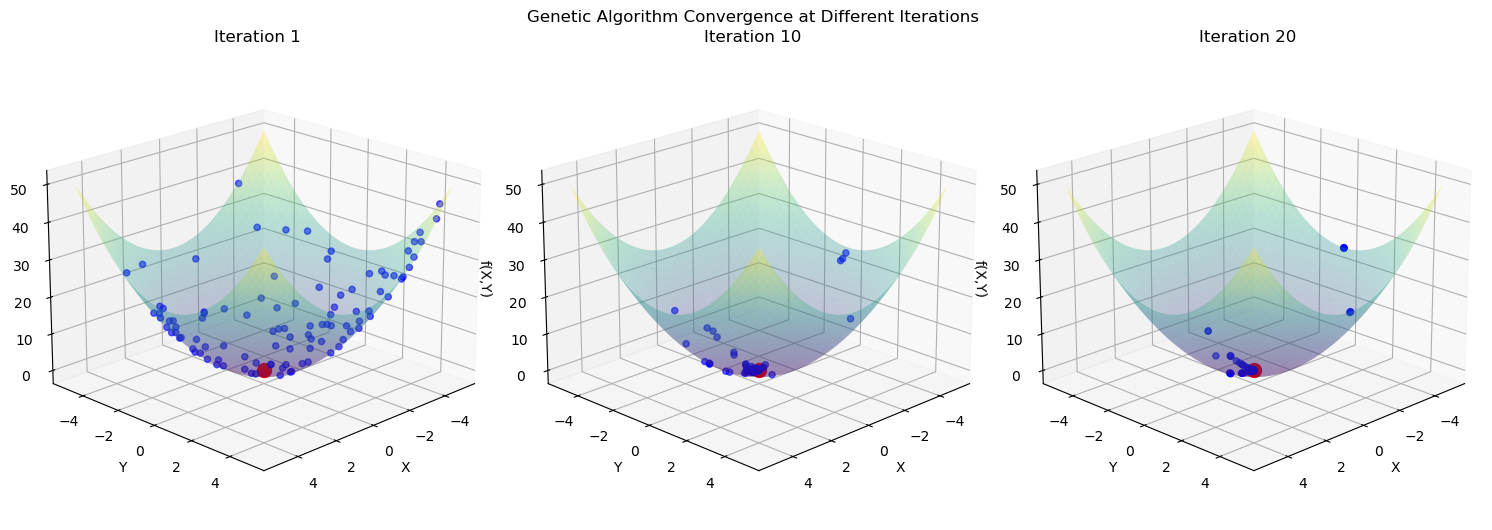

In [4]:
from numpy.random import randint
from numpy.random import rand
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# [Previous function definitions remain the same: objective, decode, selection, crossover, mutation]

def genetic_algorithm(objective, bounds, n_bits, n_iter, n_pop, r_cross, r_mut):
    pop = [randint(0, 2, n_bits*len(bounds)).tolist() for _ in range(n_pop)]
    best, best_eval = 0, objective(decode(bounds, n_bits, pop[0]))
    history = []
    
    for gen in range(n_iter):
        decoded = [decode(bounds, n_bits, p) for p in pop]
        scores = [objective(d) for d in decoded]
        history.append(decoded)
        
        for i in range(n_pop):
            if scores[i] < best_eval:
                best, best_eval = pop[i], scores[i]
                print(">%d, new best f(%s) = %f" % (gen, decoded[i], scores[i]))
                
        selected = [selection(pop, scores) for _ in range(n_pop)]
        children = list()
        for i in range(0, n_pop, 2):
            p1, p2 = selected[i], selected[i+1]
            for c in crossover(p1, p2, r_cross):
                mutation(c, r_mut)
                children.append(c)
        pop = children
    
    return [best, best_eval, history]

# Parameters
bounds = [[-5.0, 5.0], [-5.0, 5.0]]
n_iter = 100
n_bits = 16
n_pop = 100
r_cross = 0.9
r_mut = 1.0 / (float(n_bits) * len(bounds))

# Run algorithm
best, score, history = genetic_algorithm(objective, bounds, n_bits, n_iter, n_pop, r_cross, r_mut)
decoded_best = decode(bounds, n_bits, best)
print('Done!')
print('f(%s) = %f' % (decoded_best, score))

# Create surface data
x = np.linspace(bounds[0][0], bounds[0][1], 50)
y = np.linspace(bounds[1][0], bounds[1][1], 50)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

# Create subplots
fig = plt.figure(figsize=(15, 5))
iterations = [0, 9, 19]  # 1st, 10th, and 20th iterations
titles = ['Iteration 1', 'Iteration 10', 'Iteration 20']

for i, iter_idx in enumerate(iterations):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    # Plot surface
    ax.plot_surface(X, Y, Z, alpha=0.3, cmap='viridis')
    
    # Plot population
    xs = [ind[0] for ind in history[iter_idx]]
    ys = [ind[1] for ind in history[iter_idx]]
    zs = [objective(ind) for ind in history[iter_idx]]
    ax.scatter(xs, ys, zs, c='blue', alpha=0.6)
    
    # Plot best solution
    ax.scatter(decoded_best[0], decoded_best[1], score, c='red', s=100)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('f(X,Y)')
    ax.set_title(titles[i])
    ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.suptitle('Genetic Algorithm Convergence at Different Iterations', y=1.05)
plt.show()